# STEP 1

In [17]:
# Install dependencies as needed:
#!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

C:\Users\Oguzh\AppData\Local\Temp\ipykernel_5280\2496438784.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

In [18]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [19]:
import pandas as pd

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [20]:
print(df.shape)

(7032, 21)


In [21]:
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [22]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
#!pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(5625, 19) (1407, 19)


# STEP 2

In [25]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

categorical_features = [col for col in X_train.columns if col not in numeric_features]

In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Model 1 – Logistic Regression**

In [27]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        C=1.0,
        penalty="l2"
    ))
])

logreg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Model 2 – Gradient Boosting**

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gbdt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
gbdt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Evaluation**

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_log = logreg_pipeline.predict(X_test)
y_proba_log = logreg_pipeline.predict_proba(X_test)[:,1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression
Accuracy: 0.8038379530916845
Precision: 0.6484848484848484
Recall: 0.5721925133689839
F1: 0.6079545454545454
ROC-AUC: 0.8359290473207676


In [30]:
y_pred_log = gbdt_pipeline.predict(X_test)
y_proba_log = gbdt_pipeline.predict_proba(X_test)[:,1]

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Gradient Boosting
Accuracy: 0.7924662402274343
Precision: 0.6305732484076433
Recall: 0.5294117647058824
F1: 0.5755813953488372
ROC-AUC: 0.8392214669903868


In [31]:
## Plots (largest)

In [32]:
# Churn Distribution Plot

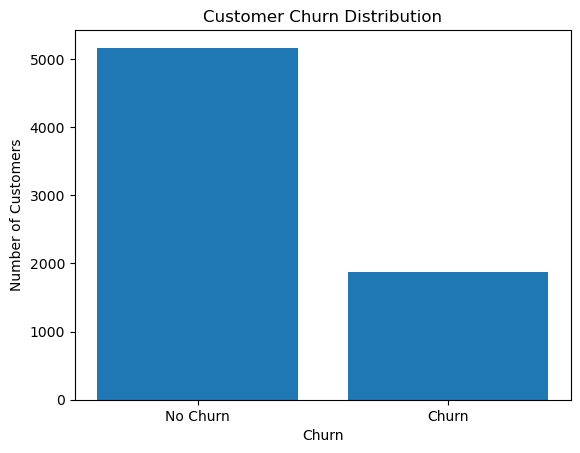

In [33]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure()
plt.bar(["No Churn", "Churn"], churn_counts.sort_index())
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Churn")
plt.show()

In [34]:
# Model Performance Comparison Plot

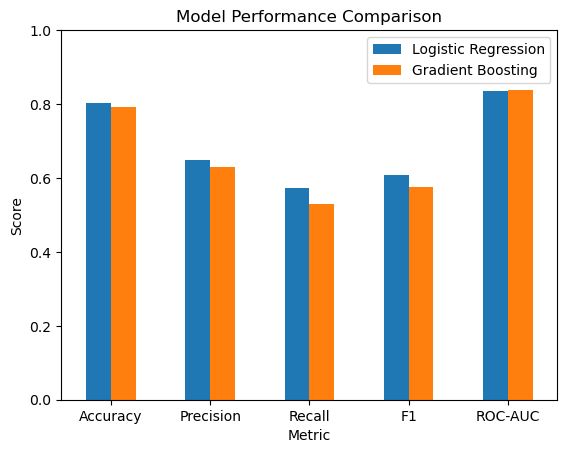

In [35]:
import pandas as pd

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, logreg_pipeline.predict(X_test)),
        precision_score(y_test, logreg_pipeline.predict(X_test)),
        recall_score(y_test, logreg_pipeline.predict(X_test)),
        f1_score(y_test, logreg_pipeline.predict(X_test)),
        roc_auc_score(y_test, logreg_pipeline.predict_proba(X_test)[:,1])
    ],
    "Gradient Boosting": [
        accuracy_score(y_test, gbdt_pipeline.predict(X_test)),
        precision_score(y_test, gbdt_pipeline.predict(X_test)),
        recall_score(y_test, gbdt_pipeline.predict(X_test)),
        f1_score(y_test, gbdt_pipeline.predict(X_test)),
        roc_auc_score(y_test, gbdt_pipeline.predict_proba(X_test)[:,1])
    ]
})

metrics.set_index("Metric").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [36]:
# Logistic Regression Feature Importance Plot

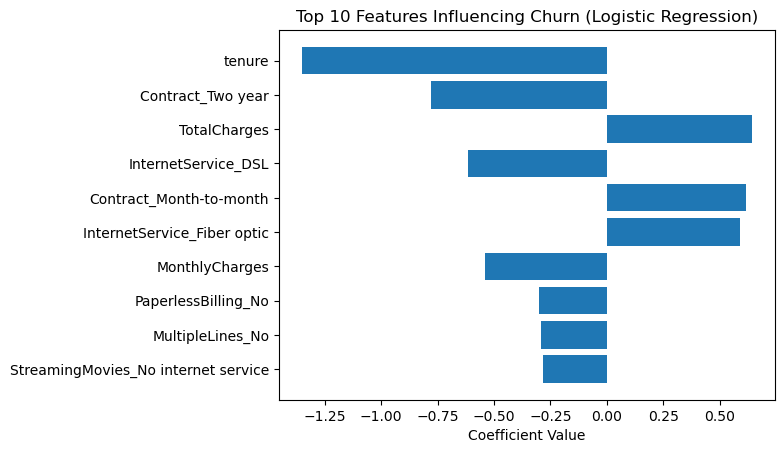

In [37]:
import numpy as np

feature_names = (
    numeric_features +
    list(logreg_pipeline.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(categorical_features))
)

coefficients = logreg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["Coefficient"].abs()

top_features = coef_df.sort_values("abs_coef", ascending=False).head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 10 Features Influencing Churn (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.show()